In [18]:
from typing import *
import random
from langgraph.graph import StateGraph, START, END


In [19]:
class AgentState(TypedDict):

    name : str
    attempts : int
    target_number : int
    lower_bound : int
    upper_bound : int
    guesses : List[int]


In [23]:
def setup_node(state : AgentState) -> AgentState:
    """
    This function sets up the game by generating a random target number between the lower and upper bounds
    """
    print("In the Setup Node")
    state["attempts"] = 0
    state["guesses"] = []
    state["target_number"] = random.randint(state["lower_bound"], state["upper_bound"])
    print(f"Target Number: {state['target_number']}")
    return state

def guess_node(state : AgentState) -> AgentState:
    """
    This function guesses a number between the lower and upper bounds
    """
    print("In the Guess Node")
    guess = random.randint(state["lower_bound"], state["upper_bound"])
    state["attempts"] += 1
    state["guesses"].append(guess)
    return state

def hint_node(state : AgentState) -> AgentState:
    """
    This function will give a hunt if the number is higher or lower
    We need to take this into account and then loop back to the guess node by changing the lower or upper bound
    """
    print("In the Hint Node")
    
    print(f"Guess {state['attempts']}: {state['guesses'][-1]}")
    if state["guesses"][-1] < state["target_number"]:
        print("NUMBER IS HIGHER")
        state["lower_bound"] = state["guesses"][-1]
    else:
        print("NUMBER IS LOWER")
        state["upper_bound"] = state["guesses"][-1]
    return state

def should_continue(state : AgentState) -> AgentState:
    """
    This function will check if the game should continue
    """
    print("In the Should Continue Node")
    if state["attempts"] < 7:
        return "guessEdge"
    else:
        return "exitEdge"


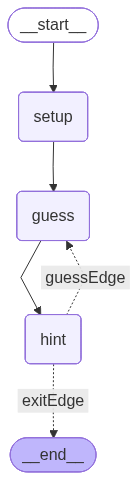

In [24]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint", hint_node)

graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")
graph.add_conditional_edges(
    "hint", # Source Node
    should_continue, # Action Function
    {
        "guessEdge" : "guess" , # Next Node if the condition is met
        "exitEdge" : END # Next Node if the condition is not met
    }
)

graph.set_entry_point("setup")
graph.compile()



In [25]:
app = graph.compile()

result = app.invoke({"name" : "Aditya", "lower_bound" : 0, "upper_bound" : 100})
print(result)


In the Setup Node
Target Number: 81
In the Guess Node
In the Hint Node
Guess 1: 1
NUMBER IS HIGHER
In the Should Continue Node
In the Guess Node
In the Hint Node
Guess 2: 13
NUMBER IS HIGHER
In the Should Continue Node
In the Guess Node
In the Hint Node
Guess 3: 19
NUMBER IS HIGHER
In the Should Continue Node
In the Guess Node
In the Hint Node
Guess 4: 73
NUMBER IS HIGHER
In the Should Continue Node
In the Guess Node
In the Hint Node
Guess 5: 78
NUMBER IS HIGHER
In the Should Continue Node
In the Guess Node
In the Hint Node
Guess 6: 97
NUMBER IS LOWER
In the Should Continue Node
In the Guess Node
In the Hint Node
Guess 7: 80
NUMBER IS HIGHER
In the Should Continue Node
{'name': 'Aditya', 'attempts': 7, 'target_number': 81, 'lower_bound': 80, 'upper_bound': 97, 'guesses': [1, 13, 19, 73, 78, 97, 80]}
